# Clinical Appointment No-Show Prediction (Milestone 1)

This notebook implements a machine learning system to predict patient appointment no-shows using classical ML models.

Models Used:
- Logistic Regression (Pipeline)
- Decision Tree (Tuned)
- Neural Network (MLP)

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC


# Datset Loading and Importing Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [39]:
df = pd.read_csv("KaggleV2-May-2016-v2.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62.0,JARDIM DA PENHA,0.0,1.0,0.0,0.0,0.0,0.0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,0.0,0.0,0.0,0.0,0.0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62.0,MATA DA PRAIA,0.0,0.0,0.0,0.0,0.0,0.0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8.0,PONTAL DE CAMBURI,0.0,0.0,0.0,0.0,0.0,0.0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56.0,JARDIM DA PENHA,0.0,1.0,1.0,0.0,0.0,0.0,No


# EDA

In [40]:
df.shape

(110527, 14)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          106660 non-null  object 
 3   ScheduledDay    106638 non-null  object 
 4   AppointmentDay  106707 non-null  object 
 5   Age             106702 non-null  float64
 6   Neighbourhood   106635 non-null  object 
 7   Scholarship     106752 non-null  float64
 8   Hipertension    106712 non-null  float64
 9   Diabetes        106709 non-null  float64
 10  Alcoholism      106764 non-null  float64
 11  Handcap         106693 non-null  float64
 12  SMS_received    106702 non-null  float64
 13  No-show         106673 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 11.8+ MB


Missing Values

In [42]:
df.isnull().sum()

,0
PatientId,0
AppointmentID,0
Gender,3867
ScheduledDay,3889
AppointmentDay,3820
Age,3825
Neighbourhood,3892
Scholarship,3775
Hipertension,3815
Diabetes,3818


Target Distribution

Dataset is imbalanced.
Accuracy alone is misleading.

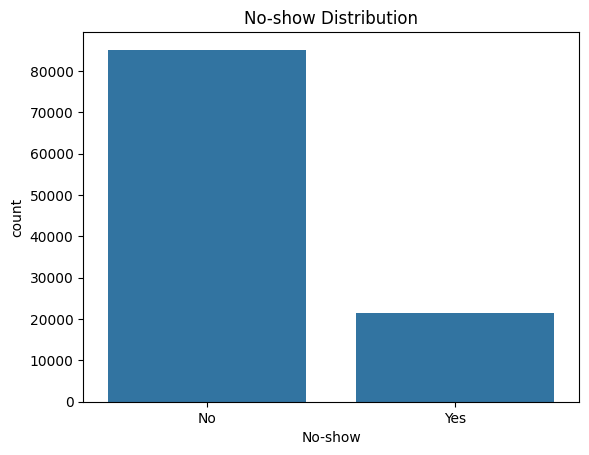


Class Distribution:
 No-show
No     0.79785
Yes    0.20215
Name: proportion, dtype: float64


In [43]:
sns.countplot(x='No-show', data=df)
plt.title("No-show Distribution")
plt.show()

print("\nClass Distribution:\n", df['No-show'].value_counts(normalize=True))

Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

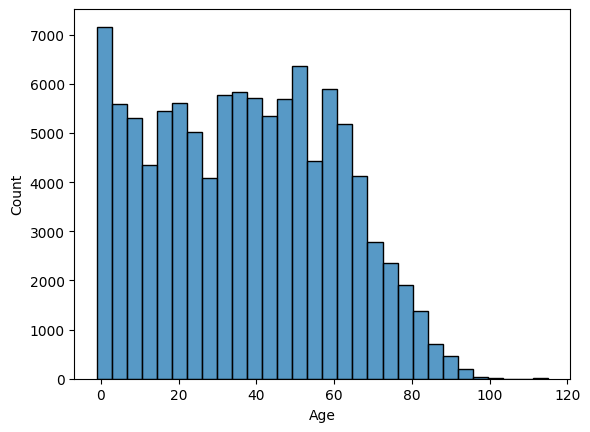

In [44]:
sns.histplot(df['Age'], bins=30)

# Pre-processing and Feature Engineering

Handling missing values

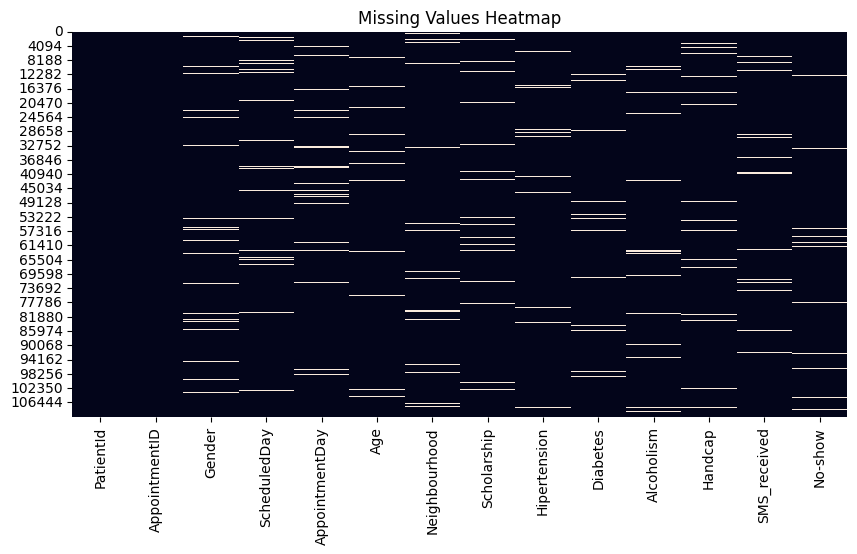

In [45]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

We use median for numerical columns because it is robust to outliers.

We use mode for categorical columns because it preserves most frequent category.

We avoid dropping rows to retain maximum data.

In [46]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical columns → fill with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categorical columns → fill with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

/tmp/ipython-input-3246859186.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3246859186.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

Missing Values After Cleaning:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


In [47]:
# Remove invalid age
df = df[df['Age'] >= 0]

In [48]:
# Dropping Irrelevant Columns
# IDs do not contribute to prediction and may cause data leakage.
df = df.drop(['PatientId', 'AppointmentID'], axis=1)

In [49]:
# Convert Dates
# Lead time reflects scheduling delay and is strongly correlated with no-shows.
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

In [50]:
# Waiting Days
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

In [51]:
# Day of the week
df['appointment_day_of_week'] = df['AppointmentDay'].dt.dayofweek

In [52]:
# Dropping original Date Column
df = df.drop(['ScheduledDay', 'AppointmentDay'], axis=1)

In [53]:
# Encode Target (Convert Target to Binary)
# 1 = No-show
# 0 = Show
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

In [54]:
# Encode Gender
df['Gender'] = df['Gender'].map({'M':1, 'F':0})

In [55]:
# Drop Neighbourhood
df = df.drop('Neighbourhood', axis=1)

In [56]:
df['No-show'].value_counts()

,count
No-show,
0,88962
1,21564


In [57]:
# Split Data
X = df.drop('No-show', axis=1)
y = df['No-show']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

The dataset is imbalanced, with significantly more patients attending appointments than missing them.
Therefore, we use F1-score and Recall as primary evaluation metrics instead of Accuracy.

In [58]:
print("Class Distribution:")
print(y.value_counts())
print("\nPercentage:")
print(y.value_counts(normalize=True) * 100)

Class Distribution:
No-show
0    88962
1    21564
Name: count, dtype: int64

Percentage:
No-show
0    80.489659
1    19.510341
Name: proportion, dtype: float64


In [59]:
# Scale Numeric Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models


In [60]:
# Model 1: Logistic Regression
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [61]:
# Model 2: Decision Tree
# Trees are scale-invariant because they split based on thresholds, not distances or gradients.
param_grid_tree = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_tree,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

best_tree_model = grid_tree.best_estimator_

y_pred_tree = best_tree_model.predict(X_test)
y_prob_tree = best_tree_model.predict_proba(X_test)[:,1]

print("Best Tree Params:", grid_tree.best_params_)

Best Tree Params: {'max_depth': 3, 'min_samples_split': 2}


In [62]:
# Model 3: MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)
y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]

# Model Evaluation

===== Logistic Regression =====
Accuracy: 0.6528996652492536
Precision: 0.29386503067484665
Recall: 0.5552979364711338
F1 Score: 0.38433763941266147
ROC-AUC: 0.6583926244894056


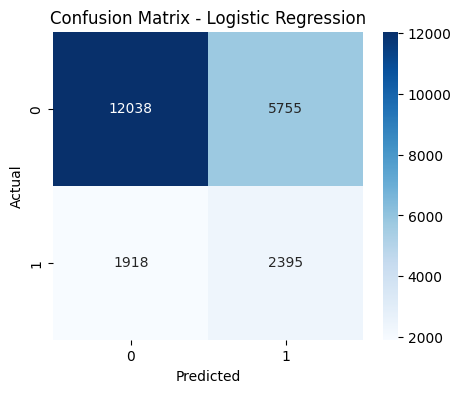



===== Decision Tree =====
Accuracy: 0.5741880032570343
Precision: 0.28538966503955565
Recall: 0.786227683746812
F1 Score: 0.4187712256869404
ROC-AUC: 0.6983196212089908


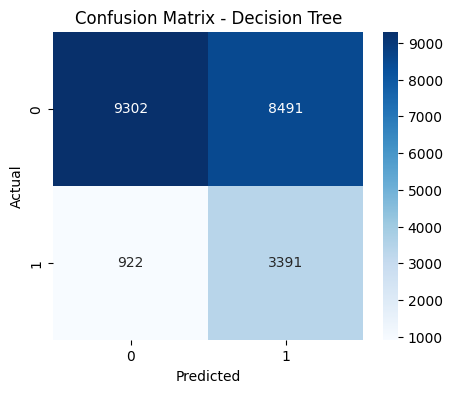



===== Neural Network (MLP) =====
Accuracy: 0.8039898670044332
Precision: 0.4090909090909091
Recall: 0.010433572919081846
F1 Score: 0.020348179968347275
ROC-AUC: 0.7028105460261903


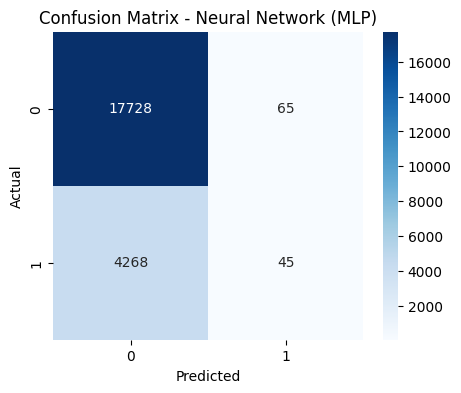

In [63]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\n")

print_metrics("Logistic Regression", y_test, y_pred_log, y_prob_log)
print_metrics("Decision Tree", y_test, y_pred_tree, y_prob_tree)
print_metrics("Neural Network (MLP)", y_test, y_pred_mlp, y_prob_mlp)

We tune the classification threshold instead of using default 0.5.
This improves F1-score by better balancing Precision and Recall.

In [64]:
from sklearn.metrics import f1_score
import numpy as np

print("Threshold Tuning for Decision Tree\n")

probs = best_tree_model.predict_proba(X_test)[:,1]

# thresholds = np.arange(0.1, 0.9, 0.05)
thresholds = np.linspace(0.1, 0.9, 100)

for t in thresholds:
    preds = (probs > t).astype(int)
    print("Threshold:", round(t,2),
          "F1:", round(f1_score(y_test, preds), 4))

Threshold Tuning for Decision Tree

Threshold: 0.1 F1: 0.3265
Threshold: 0.11 F1: 0.3265
Threshold: 0.12 F1: 0.3265
Threshold: 0.12 F1: 0.3265
Threshold: 0.13 F1: 0.3836
Threshold: 0.14 F1: 0.3836
Threshold: 0.15 F1: 0.3836
Threshold: 0.16 F1: 0.3836
Threshold: 0.16 F1: 0.3836
Threshold: 0.17 F1: 0.3836
Threshold: 0.18 F1: 0.3836
Threshold: 0.19 F1: 0.3836
Threshold: 0.2 F1: 0.3836
Threshold: 0.21 F1: 0.3836
Threshold: 0.21 F1: 0.3836
Threshold: 0.22 F1: 0.3836
Threshold: 0.23 F1: 0.4147
Threshold: 0.24 F1: 0.4147
Threshold: 0.25 F1: 0.4147
Threshold: 0.25 F1: 0.4147
Threshold: 0.26 F1: 0.4147
Threshold: 0.27 F1: 0.4147
Threshold: 0.28 F1: 0.4147
Threshold: 0.29 F1: 0.4147
Threshold: 0.29 F1: 0.4147
Threshold: 0.3 F1: 0.4147
Threshold: 0.31 F1: 0.4147
Threshold: 0.32 F1: 0.4147
Threshold: 0.33 F1: 0.4147
Threshold: 0.33 F1: 0.4147
Threshold: 0.34 F1: 0.4147
Threshold: 0.35 F1: 0.4147
Threshold: 0.36 F1: 0.4147
Threshold: 0.37 F1: 0.4147
Threshold: 0.37 F1: 0.4147
Threshold: 0.38 F1: 0.

In [65]:
print("\nThreshold Tuning (Decision Tree)")

probs = best_tree_model.predict_proba(X_test)[:,1]

for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (probs > t).astype(int)
    print("Threshold:", t,
          "F1:", round(f1_score(y_test, preds),4))


Threshold Tuning (Decision Tree)
Threshold: 0.3 F1: 0.4147
Threshold: 0.4 F1: 0.4147
Threshold: 0.5 F1: 0.4188
Threshold: 0.6 F1: 0.3707


False Negatives are critical in healthcare.
Missing a no-show prediction leads to unprepared clinics and revenue loss.
Hence, Recall is prioritized.

In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tree)

fp = cm[0,1]
fn = cm[1,0]

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 8491
False Negatives: 922


In [67]:
from sklearn.model_selection import cross_val_score

# Scale full dataset before CV (important)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X_scaled_full,
    y,
    cv=5,
    scoring='f1'
)

print("Cross Validation F1 Scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())

Cross Validation F1 Scores: [0.37743997 0.38474243 0.36343402 0.39348158 0.39867159]
Mean CV F1: 0.383553918721939


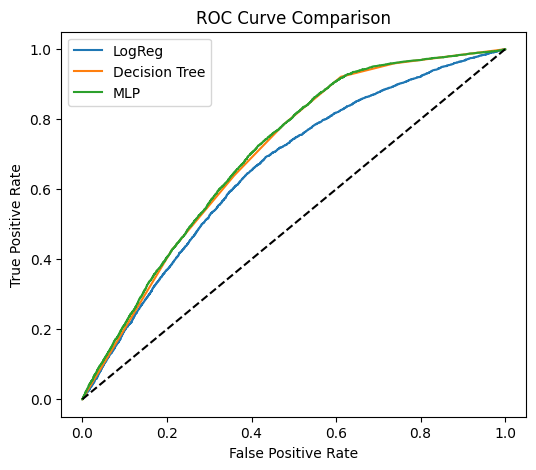

In [68]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="LogReg")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_mlp, tpr_mlp, label="MLP")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

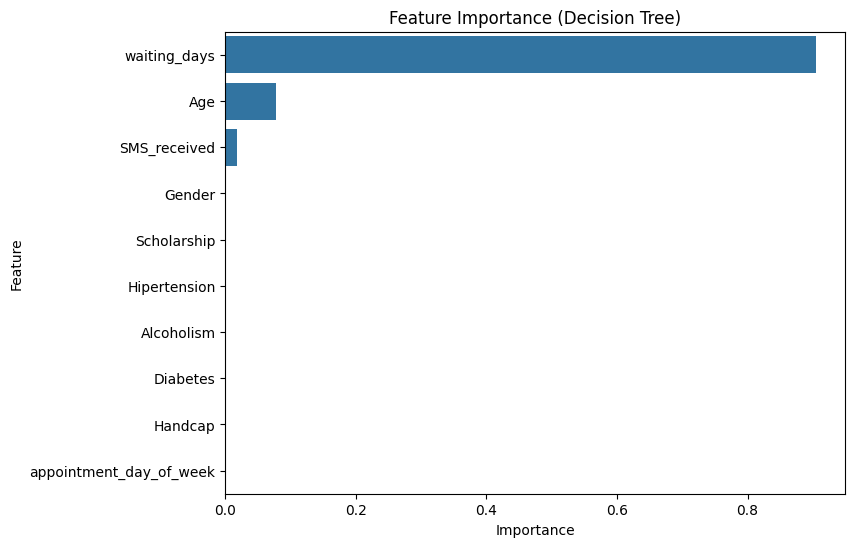

In [69]:
importances = best_tree_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance (Decision Tree)")
plt.show()

## Business Impact

If deployed, the system can:

• Send SMS reminders to high-risk patients  
• Double-book low-risk patients  
• Reduce idle doctor time  
• Improve hospital revenue efficiency  
• Improve patient scheduling optimization  

Based on F1-score and Recall performance, Decision Tree with tuned hyperparameters is selected as the final model.
It provides strong recall (detecting no-shows) while maintaining acceptable precision.

In [70]:
import pickle

# Since GridSearch was used, this is your actual best model
best_model = best_tree_model

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler (needed for Logistic + MLP)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [71]:
f1_log = f1_score(y_test, y_pred_log)
f1_tree = f1_score(y_test, y_pred_tree)
f1_mlp = f1_score(y_test, y_pred_mlp)

print("F1 Scores Comparison:")
print("Logistic Regression:", round(f1_log, 4))
print("Decision Tree:", round(f1_tree, 4))
print("MLP:", round(f1_mlp, 4))

F1 Scores Comparison:
Logistic Regression: 0.3843
Decision Tree: 0.4188
MLP: 0.0203


In [72]:
print("Best Model Selected:", best_model)

Best Model Selected: DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)


### Final Conclusion

The tuned Decision Tree achieved the highest F1-score and strong recall.
Since recall is critical in healthcare no-show prediction,
this model was selected as the final model.

This system can assist hospitals in:
• Sending reminders to high-risk patients
• Reducing missed appointments
• Optimizing doctor schedules